# Gate B6 — расширенный train-only benchmark T1

## TL;DR

Статус Gate B6: **`PASS_NO_NEW_PRIMARY`**. Новый primary не выбран: **`B7_two_regime_imm`** остаётся frozen primary suite v4. Его pooled rolling-origin MAE составляет **5.640 мм/год** против **6.311 мм/год** у B1, то есть train-only skill равен **10.6%**.

Из 23 исторически замороженных записей каталога исполнены 22; 11 прошли broad temporal screen. TabPFN исключён governance-поправкой **до загрузки весов, лицензии, predictions и scoring**. Это `train_only_internal_research`: исторический validation, раскрытый T1 test и новый holdout не загружались, поэтому утверждение о внешнем качестве запрещено.

Notebook читает только сохранённые machine artifacts и готовые PNG; обучение и скрытая перенастройка отсутствуют.

## Контекст и метод

- 11 forward-only rolling-origin outer folds — broad screen;
- 42 leave-profile-out и 12 leave-zone-out folds — spatial audit;
- transition, horizon, missingness и history diagnostics;
- conformal calibration только по inner rolling OOF residuals;
- learning curves на audit tail с неизменными гиперпараметрами;
- suite v4 выбирается по preregistered gates, а не по одному weighted score.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import Image, display

root = Path.cwd().resolve()
while not (root / 'pyproject.toml').is_file():
    root = root.parent
artifact = root / 'artifacts' / 'model_selection' / 't1_b6_expanded_v1'
figure_root = artifact / 'figures'
report = json.loads((artifact / 'gate_b6_report.json').read_text(encoding='utf-8'))
validation = json.loads((artifact / 'validation_report.json').read_text(encoding='utf-8'))
suite = json.loads((root / 'artifacts' / 'governance' / 'final_candidate_suite_v4.json').read_text(encoding='utf-8'))
environment = json.loads((artifact / 'environment_manifest.json').read_text(encoding='utf-8'))
external = json.loads((artifact / 'external_model_manifest.json').read_text(encoding='utf-8'))
analytics = json.loads((artifact / 'analytics_summary.json').read_text(encoding='utf-8'))
chart_map = json.loads((artifact / 'chart_map.json').read_text(encoding='utf-8'))
screen = pd.read_csv(artifact / 'screening_register.csv')
aggregate = pd.read_csv(artifact / 'temporal_aggregate_metrics.csv')
folds = pd.read_csv(artifact / 'temporal_fold_metrics.csv')
groups = pd.read_csv(artifact / 'group_metrics.csv')
transition = pd.read_csv(artifact / 'transition_metrics.csv')
probabilistic = pd.read_csv(artifact / 'probabilistic_metrics.csv')
learning = pd.read_csv(artifact / 'learning_curves.csv')
{
    'status': report['status'],
    'scope': report['scientific_scope'],
    'primary': suite['primary_model_id'],
    'registry/executed/advanced': (report['registry_models'], report['models_screened'], report['models_advanced']),
    'validation': validation['summary'],
}

{'status': 'PASS_NO_NEW_PRIMARY',
 'scope': 'train_only_internal_research',
 'primary': 'B7_two_regime_imm',
 'registry/executed/advanced': (23, 22, 11),
 'validation': {'checks': 106, 'failed': 0, 'passed': 106}}

## 1. Broad temporal screen

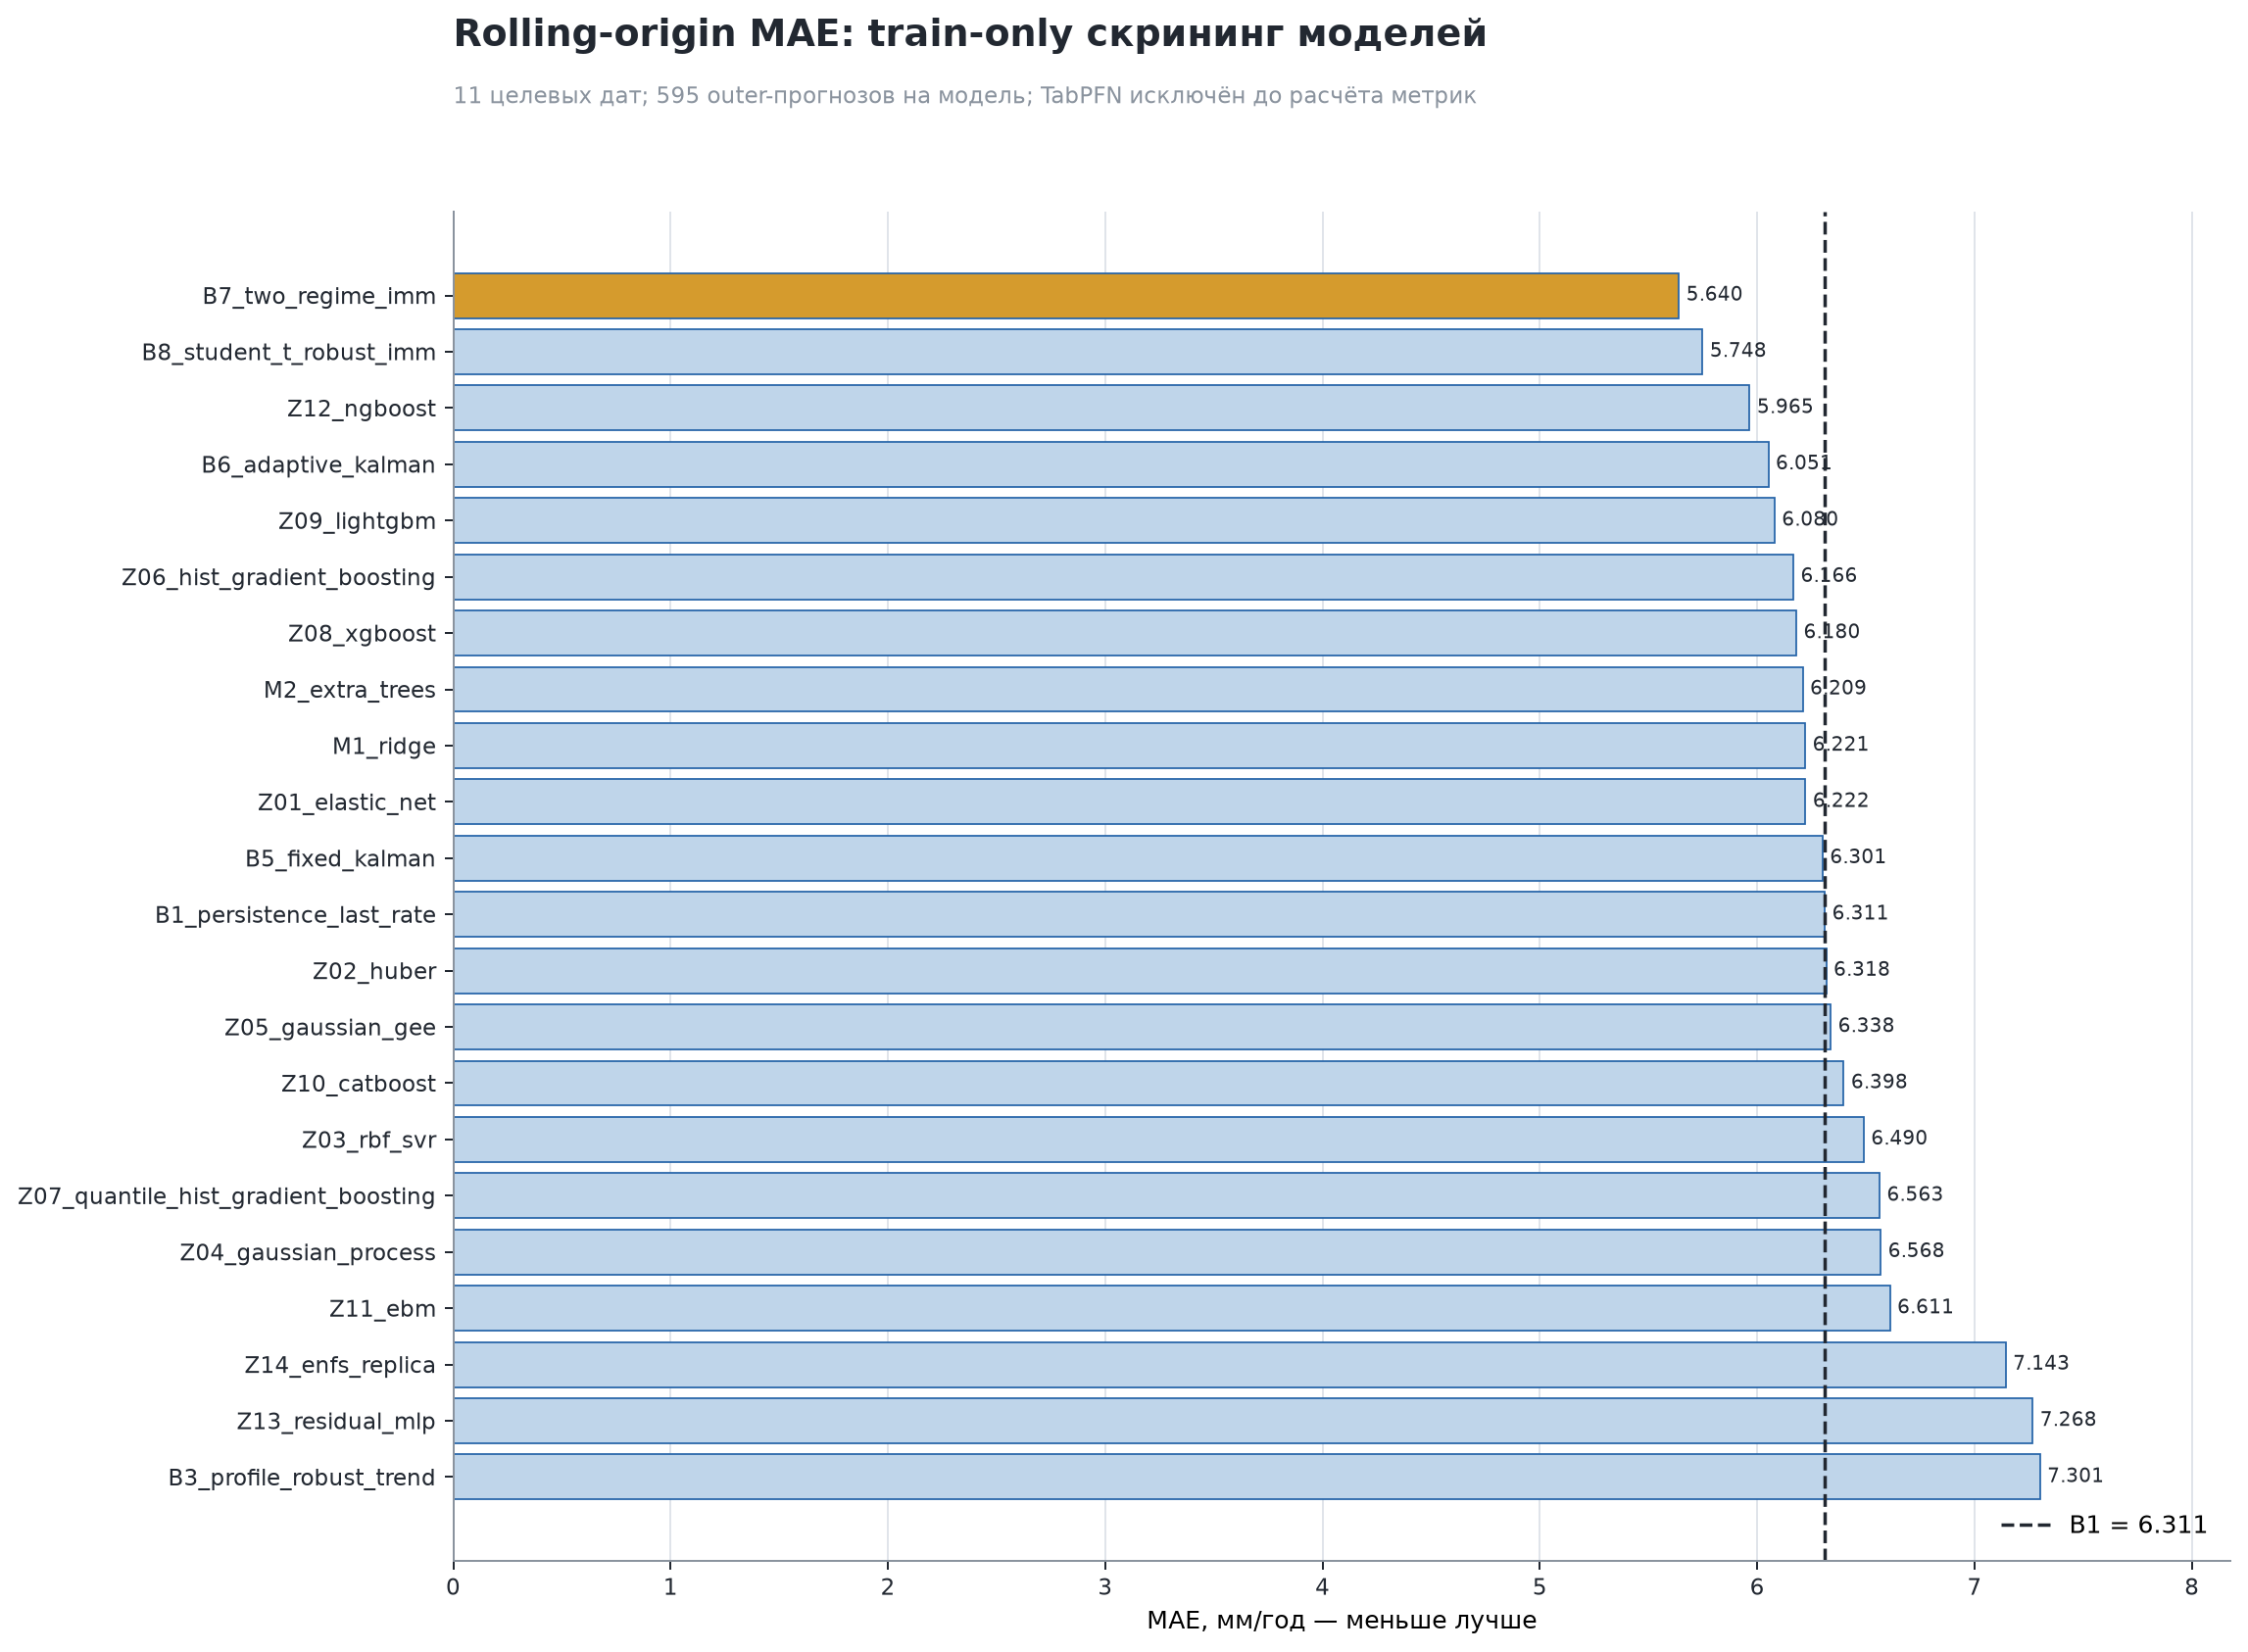

In [2]:
display(Image(filename=str(figure_root / '01_temporal_screen_mae.png'), width=1200))

In [3]:
screen_summary = screen.groupby(['screen_status', 'registry_status']).size().rename('models').to_frame()
top = aggregate.sort_values(['mae', 'model_id']).head(12)
display(screen_summary)
top[['model_id', 'mae', 'median_fold_mae', 'b1_skill', 'worst_zone_mae']].round(3)

models
screen_status                             registry_status                
EXCLUDED_GOVERNANCE_USER_WITHDRAWAL       PREREGISTERED_CANDIDATE       1
FROZEN_COMPARATOR_ADVANCED_DESPITE_SCREEN FROZEN_COMPARATOR             4
PASSED_TEMPORAL_SCREEN                    FROZEN_COMPARATOR             4
                                          PREREGISTERED_CANDIDATE       3
REJECTED_TEMPORAL_SCREEN                  PREREGISTERED_CANDIDATE      11

,model_id,mae,median_fold_mae,b1_skill,worst_zone_mae
0,B7_two_regime_imm,5.640,5.744,0.106,7.640
1,B8_student_t_robust_imm,5.748,5.764,0.089,7.977
2,Z12_ngboost,5.965,5.968,0.055,8.362
3,B6_adaptive_kalman,6.051,6.206,0.041,8.269
4,Z09_lightgbm,6.080,6.074,0.037,8.539
5,Z06_hist_gradient_boosting,6.166,6.636,0.023,8.641
6,Z08_xgboost,6.180,6.230,0.021,8.802
7,M2_extra_trees,6.209,6.598,0.016,9.039
8,M1_ridge,6.221,6.478,0.014,8.873
9,Z01_elastic_net,6.222,6.719,0.014,8.540


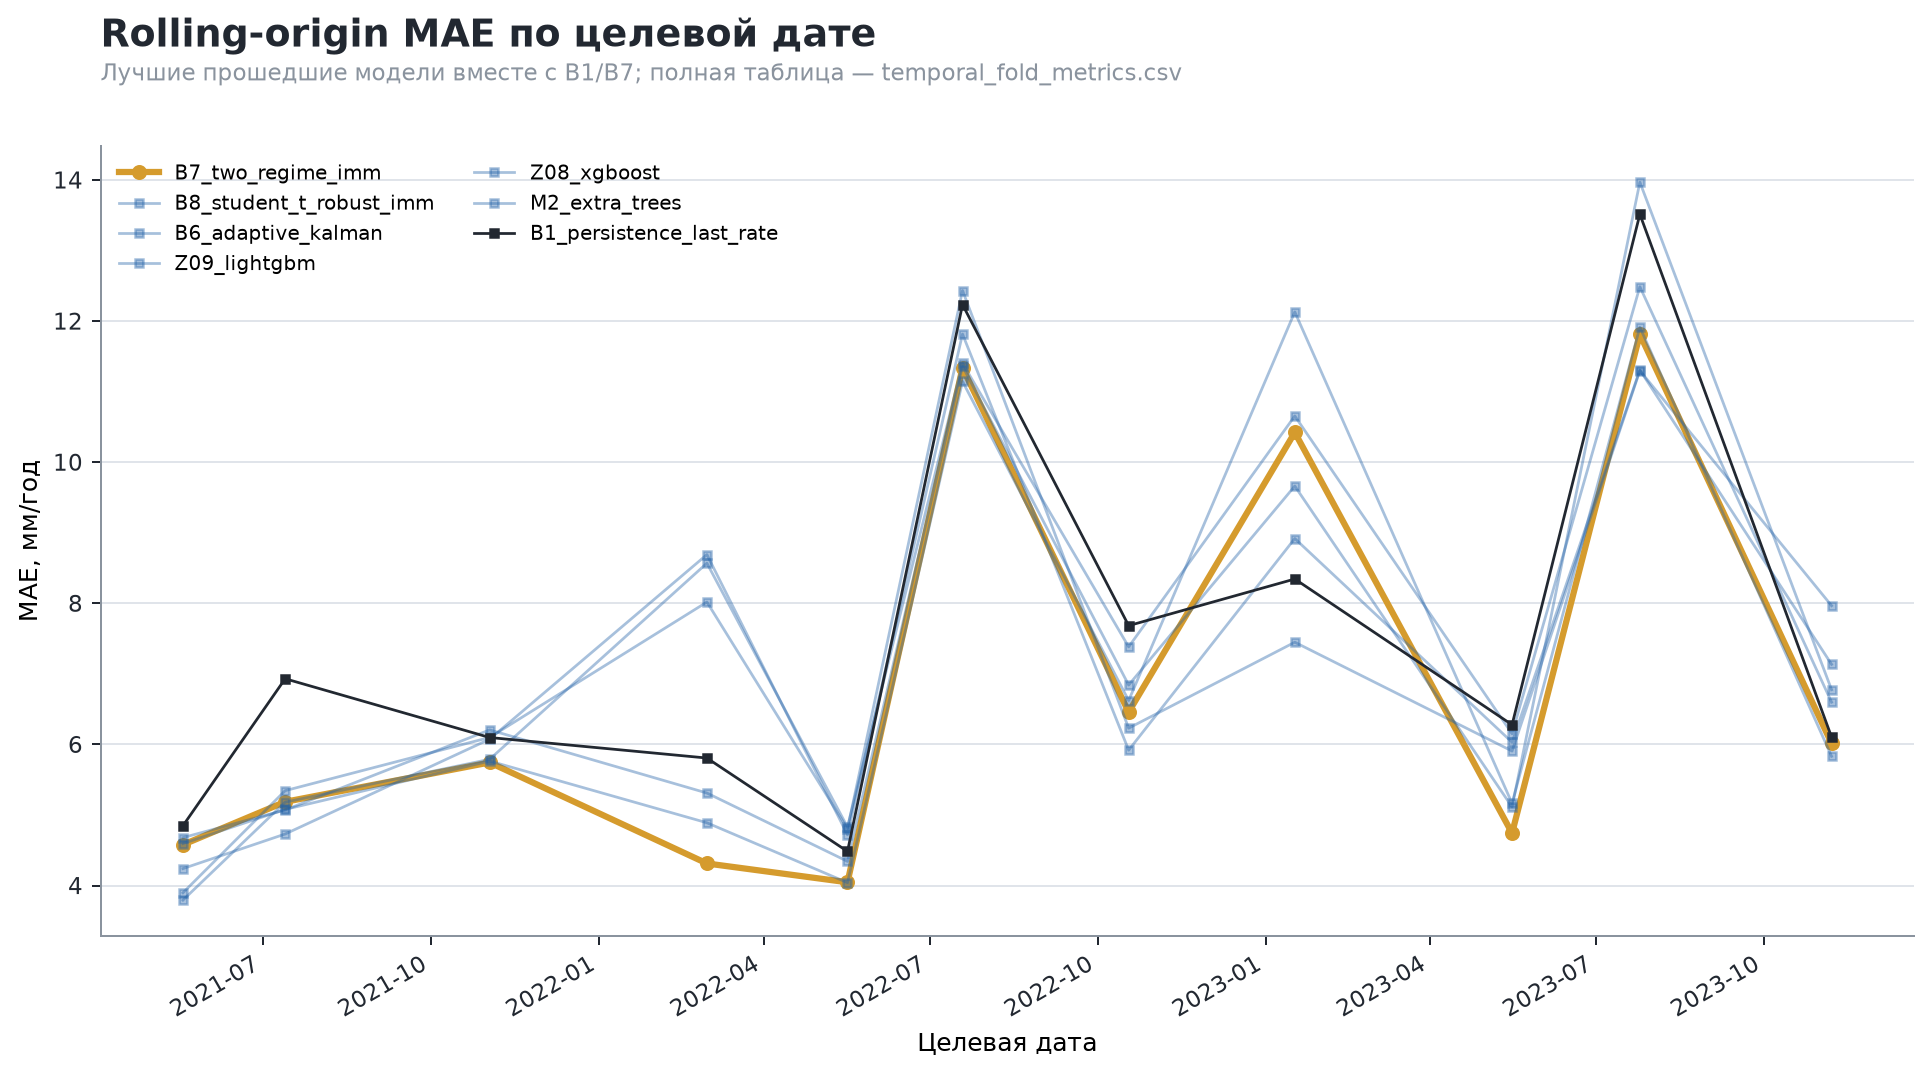

In [4]:
display(Image(filename=str(figure_root / '02_rolling_mae_by_date.png'), width=1200))

**Интерпретация.** B7 имеет лучший pooled MAE, но ошибка заметно меняется между датами. Поэтому решение не опирается только на среднее: обязательны sign consistency, spatial holdouts и transition guardrails.

## 2. Пространственная устойчивость и transition evidence

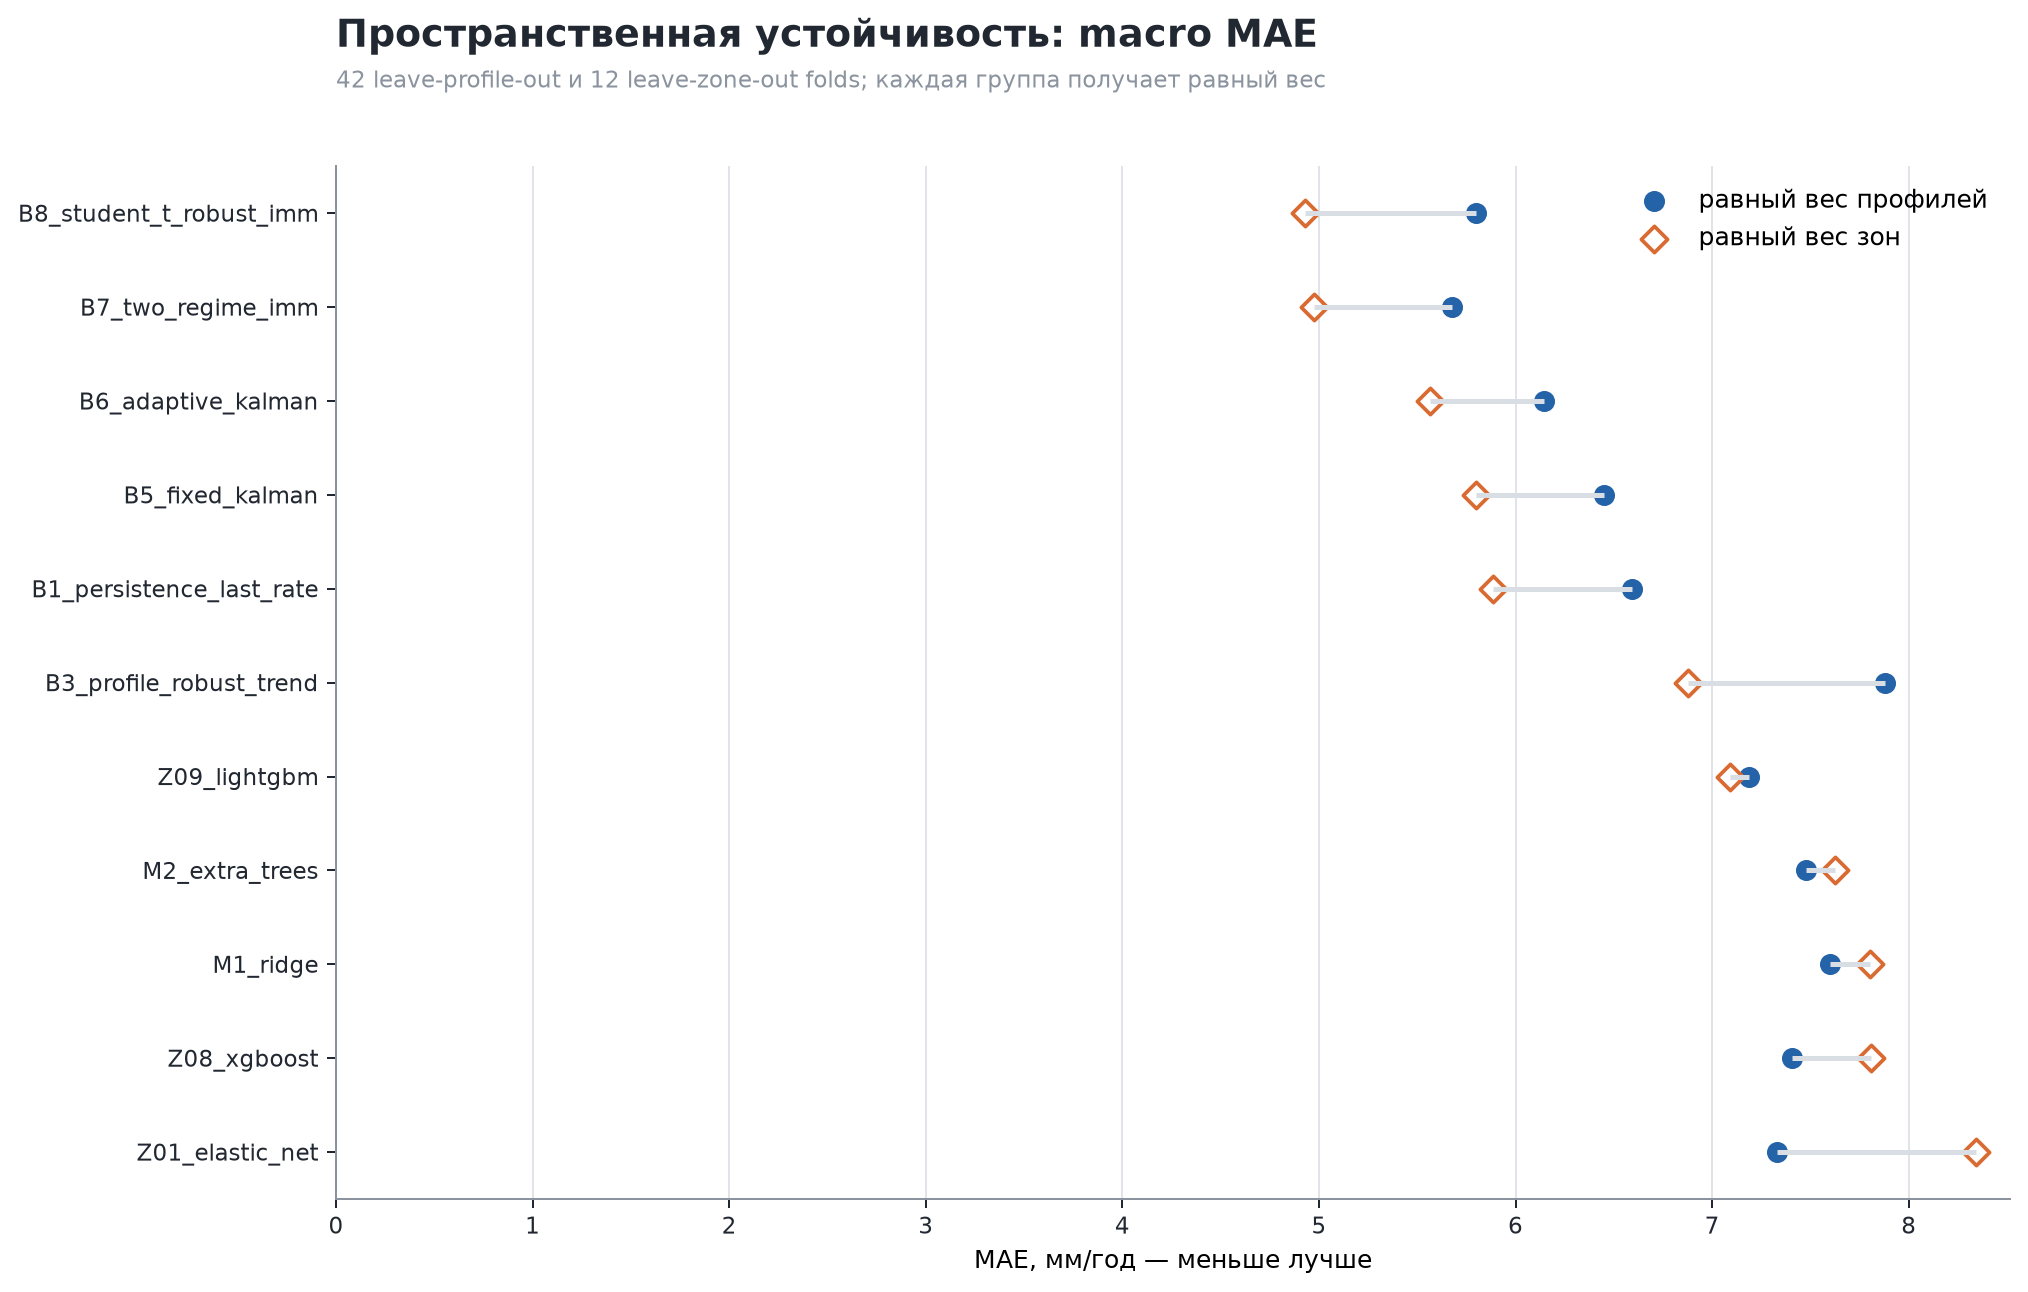

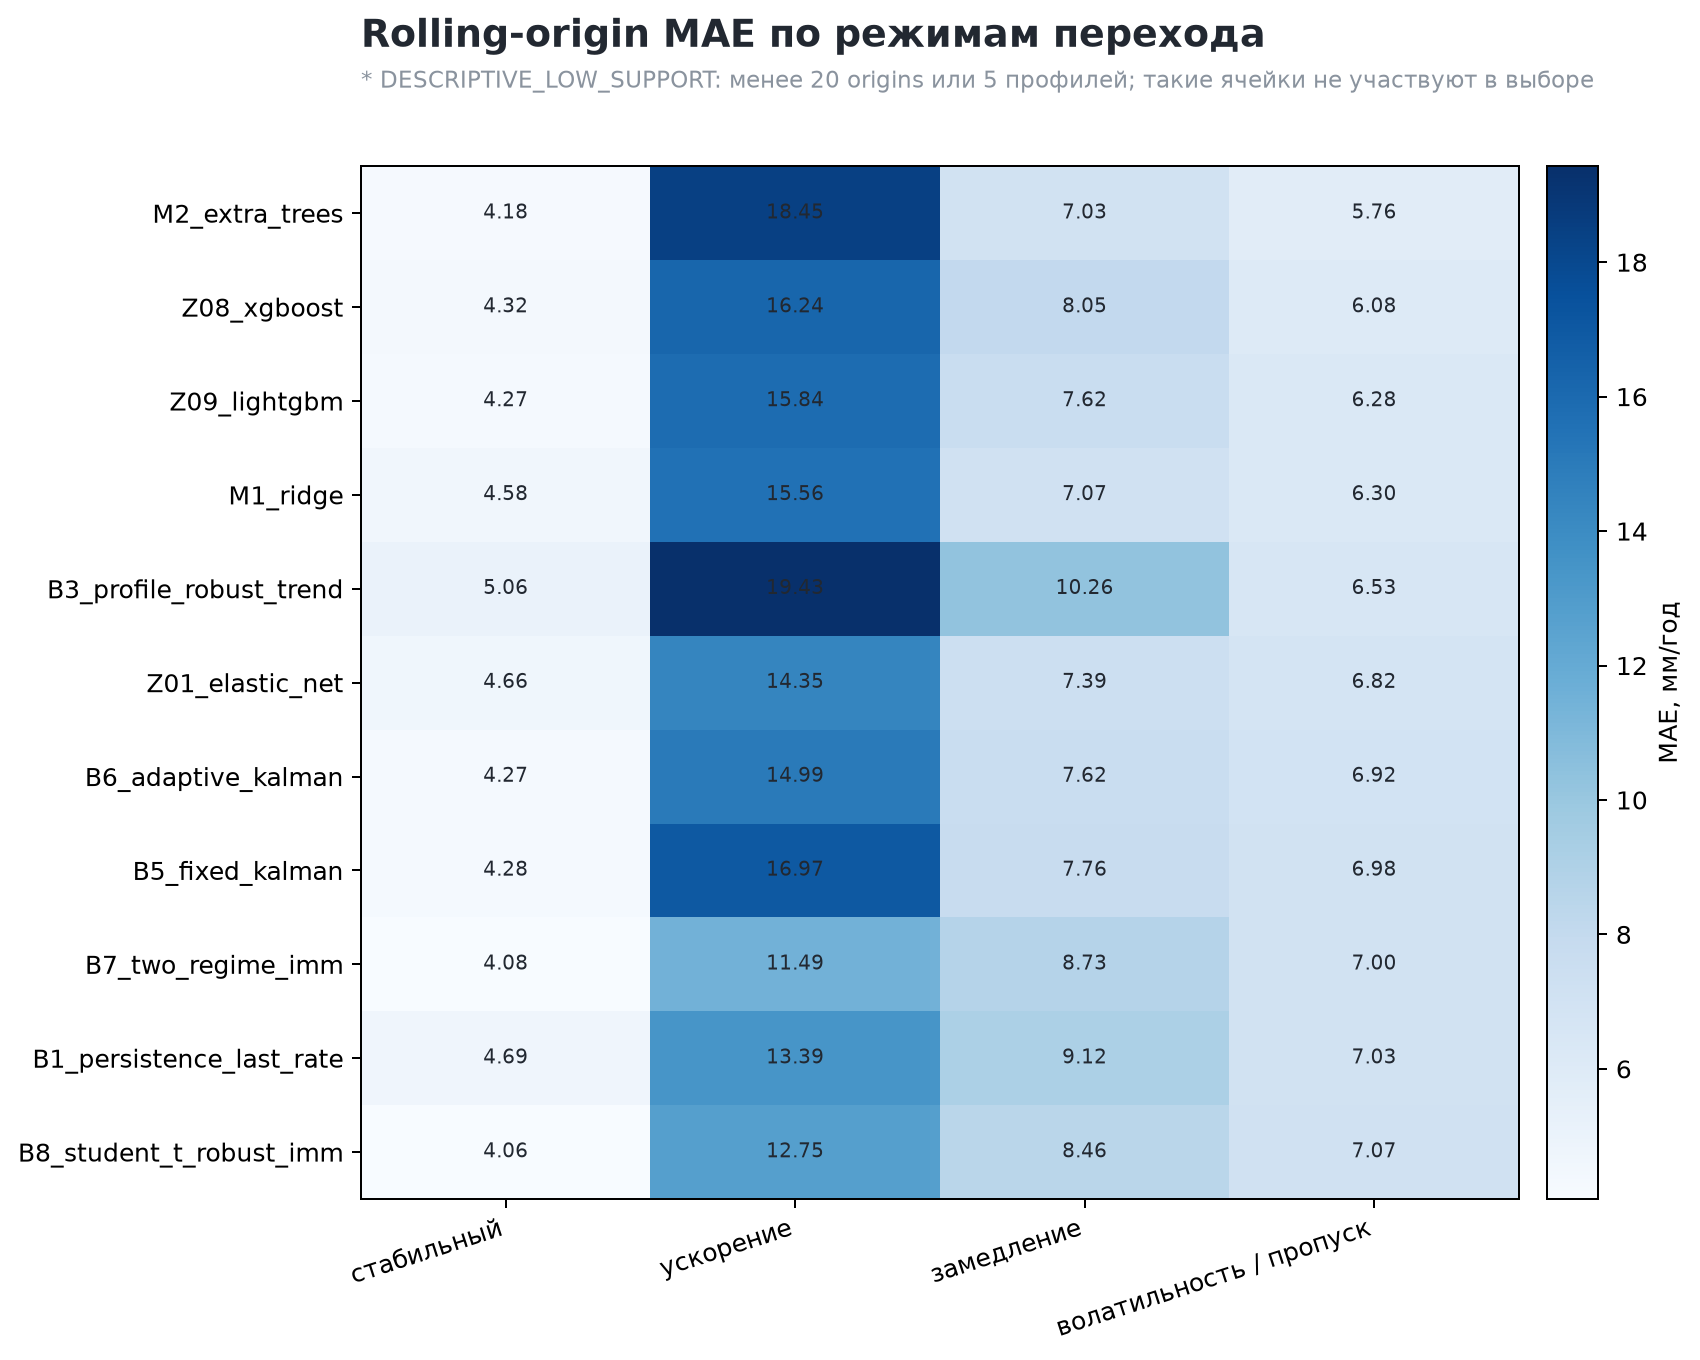

In [5]:
display(Image(filename=str(figure_root / '03_spatial_stability.png'), width=1200))
display(Image(filename=str(figure_root / '04_transition_error_heatmap.png'), width=1100))

In [6]:
macro = groups.loc[
    groups['scope'].isin(['equal_profile_macro', 'equal_zone_macro']),
    ['design', 'model_id', 'scope', 'mae'],
]
macro.pivot_table(index='model_id', columns='scope', values='mae').sort_values('equal_zone_macro').head(15).round(3)

scope,equal_profile_macro,equal_zone_macro
model_id,,
B8_student_t_robust_imm,5.798,4.928
B7_two_regime_imm,5.676,4.975
B6_adaptive_kalman,6.147,5.562
B5_fixed_kalman,6.451,5.800
B1_persistence_last_rate,6.592,5.883
B3_profile_robust_trend,7.878,6.879
Z09_lightgbm,7.187,7.093
M2_extra_trees,7.479,7.623
M1_ridge,7.600,7.801


In [7]:
transition.loc[
    transition['design'].eq('rolling_origin')
    & transition['dimension'].isin(['pooled_transition', 'transition']),
    ['model_id', 'dimension', 'segment', 'rows', 'support_status', 'mae'],
].sort_values(['dimension', 'segment', 'mae']).head(40).round(3)

,model_id,dimension,segment,rows,support_status,mae
69,B7_two_regime_imm,pooled_transition,transition,182,ELIGIBLE_SUPPORT,9.169
83,B8_student_t_robust_imm,pooled_transition,transition,182,ELIGIBLE_SUPPORT,9.572
125,Z01_elastic_net,pooled_transition,transition,182,ELIGIBLE_SUPPORT,9.762
181,Z05_gaussian_gee,pooled_transition,transition,182,ELIGIBLE_SUPPORT,9.786
97,M1_ridge,pooled_transition,transition,182,ELIGIBLE_SUPPORT,9.938
13,B1_persistence_last_rate,pooled_transition,transition,182,ELIGIBLE_SUPPORT,9.990
139,Z02_huber,pooled_transition,transition,182,ELIGIBLE_SUPPORT,10.003
279,Z12_ngboost,pooled_transition,transition,182,ELIGIBLE_SUPPORT,10.017
195,Z06_hist_gradient_boosting,pooled_transition,transition,182,ELIGIBLE_SUPPORT,10.092
55,B6_adaptive_kalman,pooled_transition,transition,182,ELIGIBLE_SUPPORT,10.101


**Интерпретация.** B7 сохраняет сильный профильный и зональный результат и лучше B1 на accelerating origins, но не улучшает B1 на volatile-or-gap. Именно поэтому volatile-or-gap остаётся жёстким guardrail, а четыре зоны трактуются описательно, без псевдо-точных confidence intervals.

## 3. Калибровка и probabilistic output

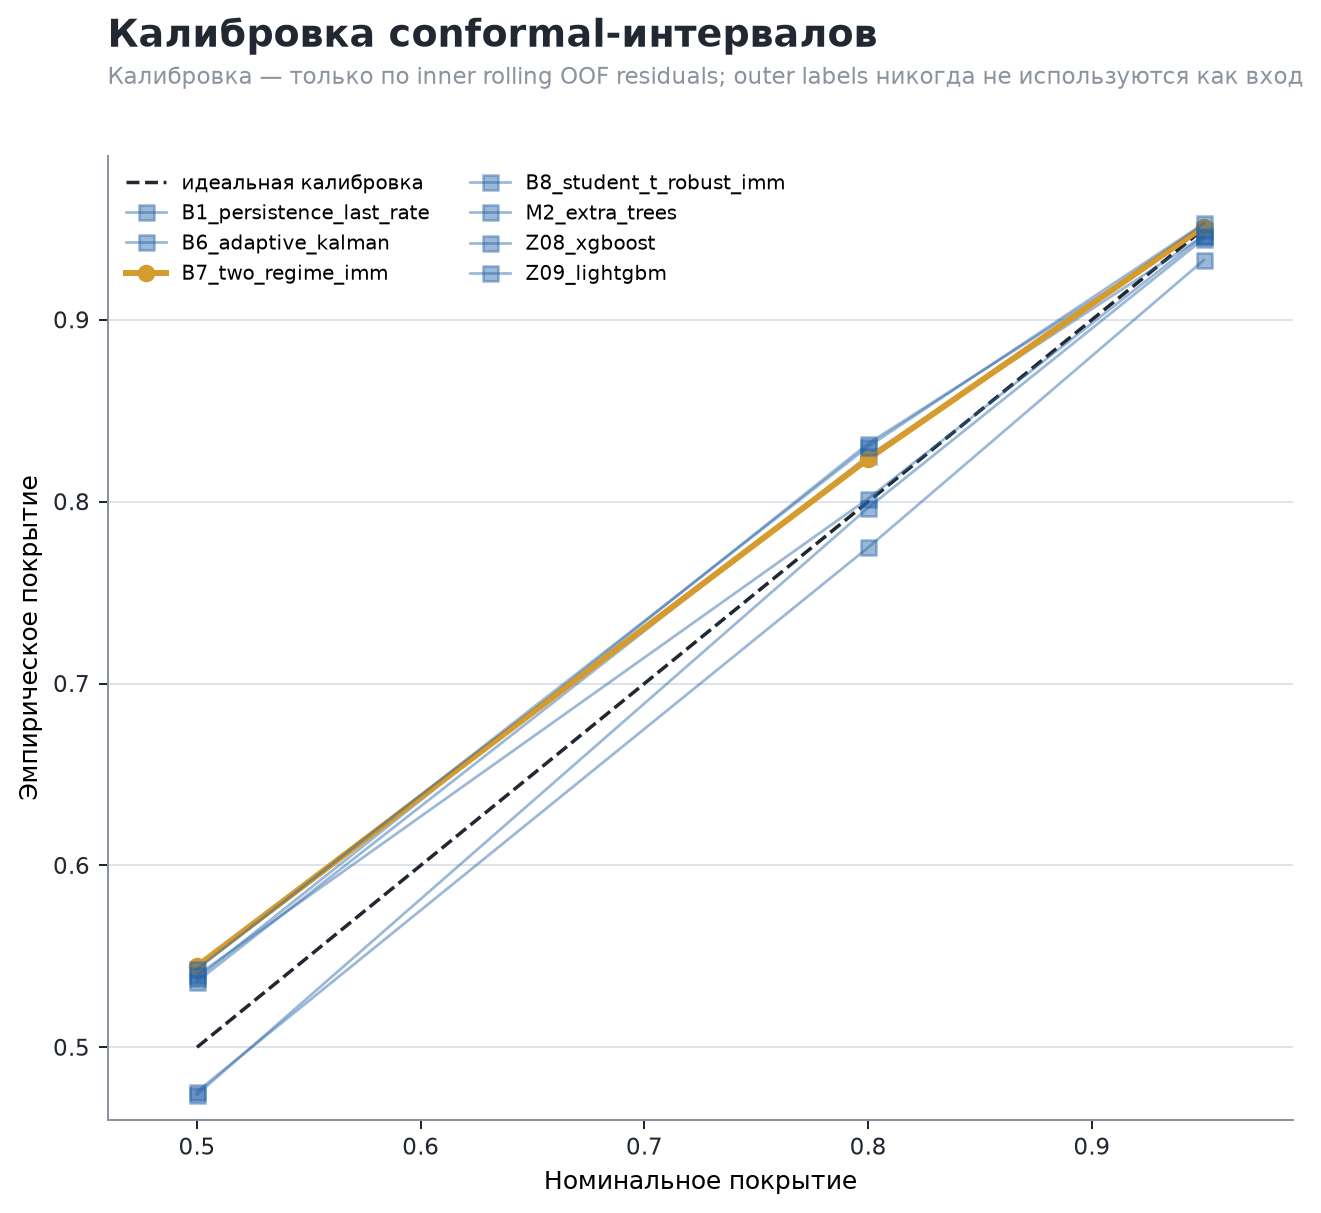

In [8]:
display(Image(filename=str(figure_root / '05_conformal_calibration.png'), width=900))

In [9]:
overall_prob = probabilistic.loc[
    probabilistic['design'].eq('rolling_origin')
    & probabilistic['dimension'].eq('overall'),
    ['model_id', 'interval_source', 'coverage_50', 'coverage_80', 'coverage_95', 'weighted_interval_score', 'crps', 'nll'],
]
overall_prob.sort_values(['interval_source', 'weighted_interval_score']).round(4)

,model_id,interval_source,coverage_50,coverage_80,coverage_95,weighted_interval_score,crps,nll
125,B7_two_regime_imm,conformalized,0.5445,0.8235,0.9513,3.7879,NaN,NaN
175,B8_student_t_robust_imm,conformalized,0.5429,0.8303,0.9529,3.9121,NaN,NaN
275,Z01_elastic_net,conformalized,0.4924,0.7866,0.9513,4.0931,NaN,NaN
75,B6_adaptive_kalman,conformalized,0.5361,0.8252,0.9462,4.0958,NaN,NaN
550,Z09_lightgbm,conformalized,0.4739,0.7966,0.9445,4.1067,NaN,NaN
625,Z12_ngboost,conformalized,0.5311,0.8050,0.9395,4.1219,NaN,NaN
450,Z06_hist_gradient_boosting,conformalized,0.4723,0.7899,0.9412,4.1657,NaN,NaN
0,B1_persistence_last_rate,conformalized,0.5378,0.8319,0.9496,4.1709,NaN,NaN
300,Z02_huber,conformalized,0.5429,0.8118,0.9479,4.2025,NaN,NaN
225,M1_ridge,conformalized,0.5412,0.8000,0.9546,4.2083,NaN,NaN


Conformal intervals публикуются отдельно от native intervals. Калибровочные residuals получены только из inner OOF predictions; outer labels используются лишь для честной оценки покрытия.

## 4. Learning curves и paired sensitivity

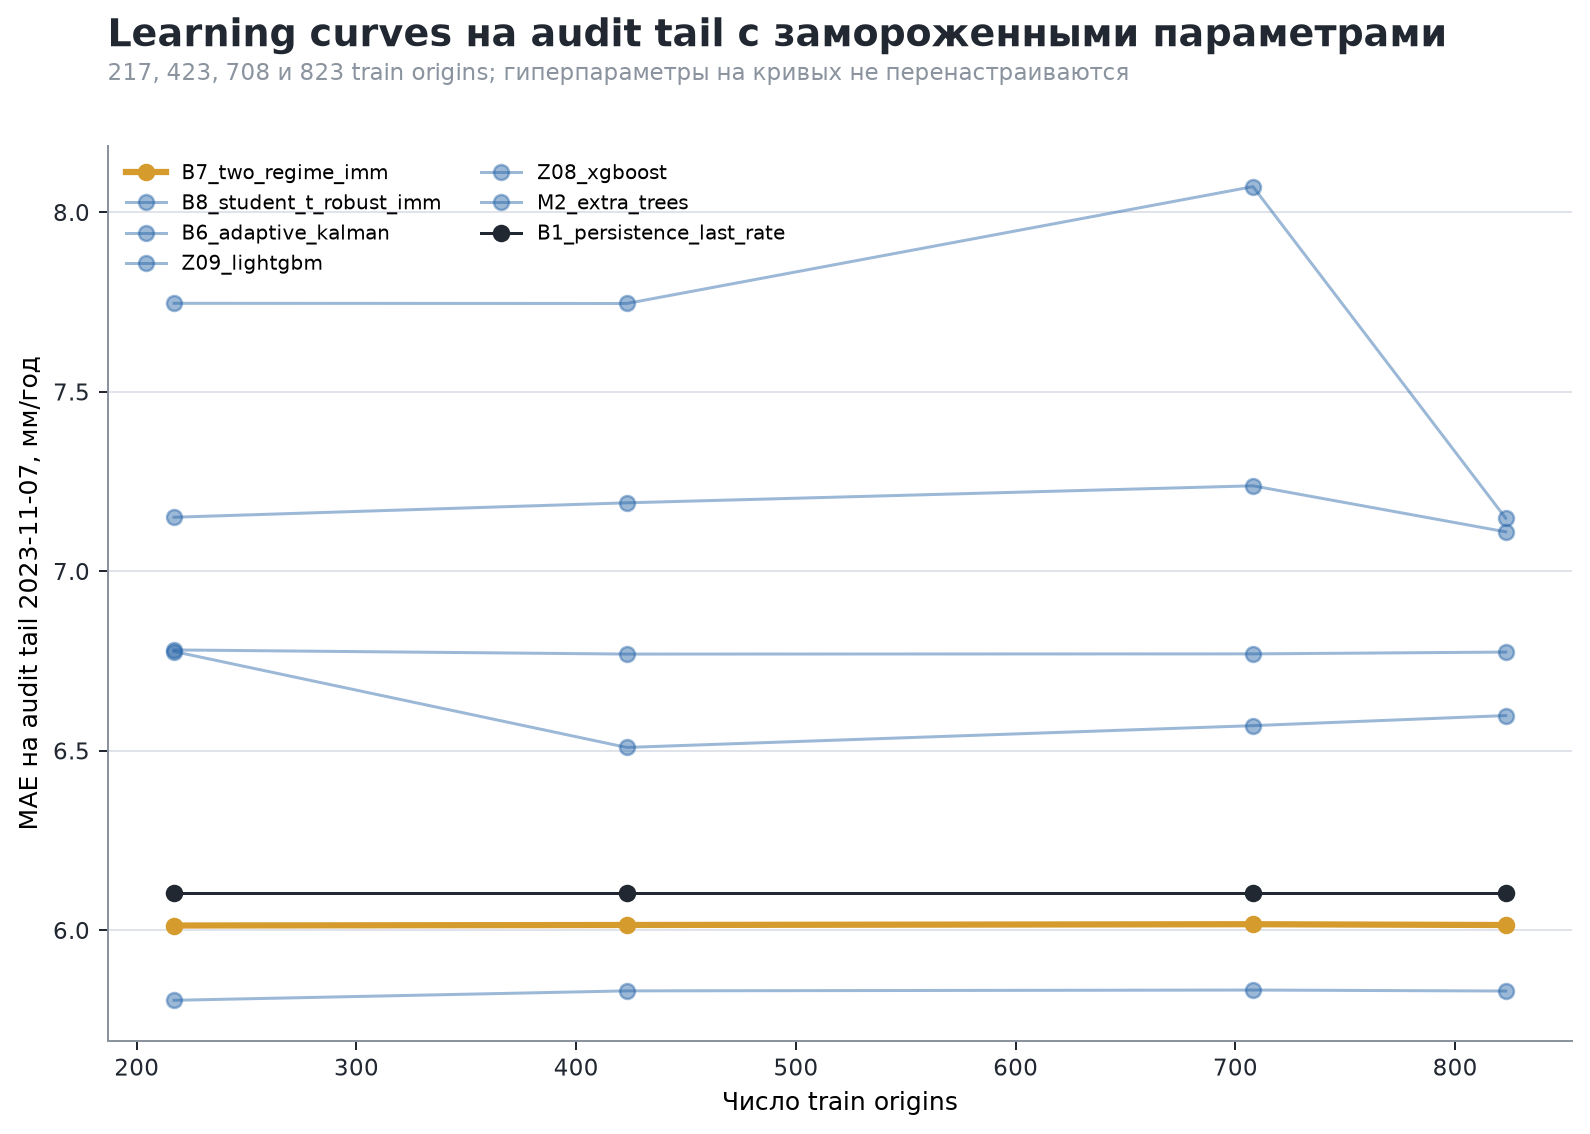

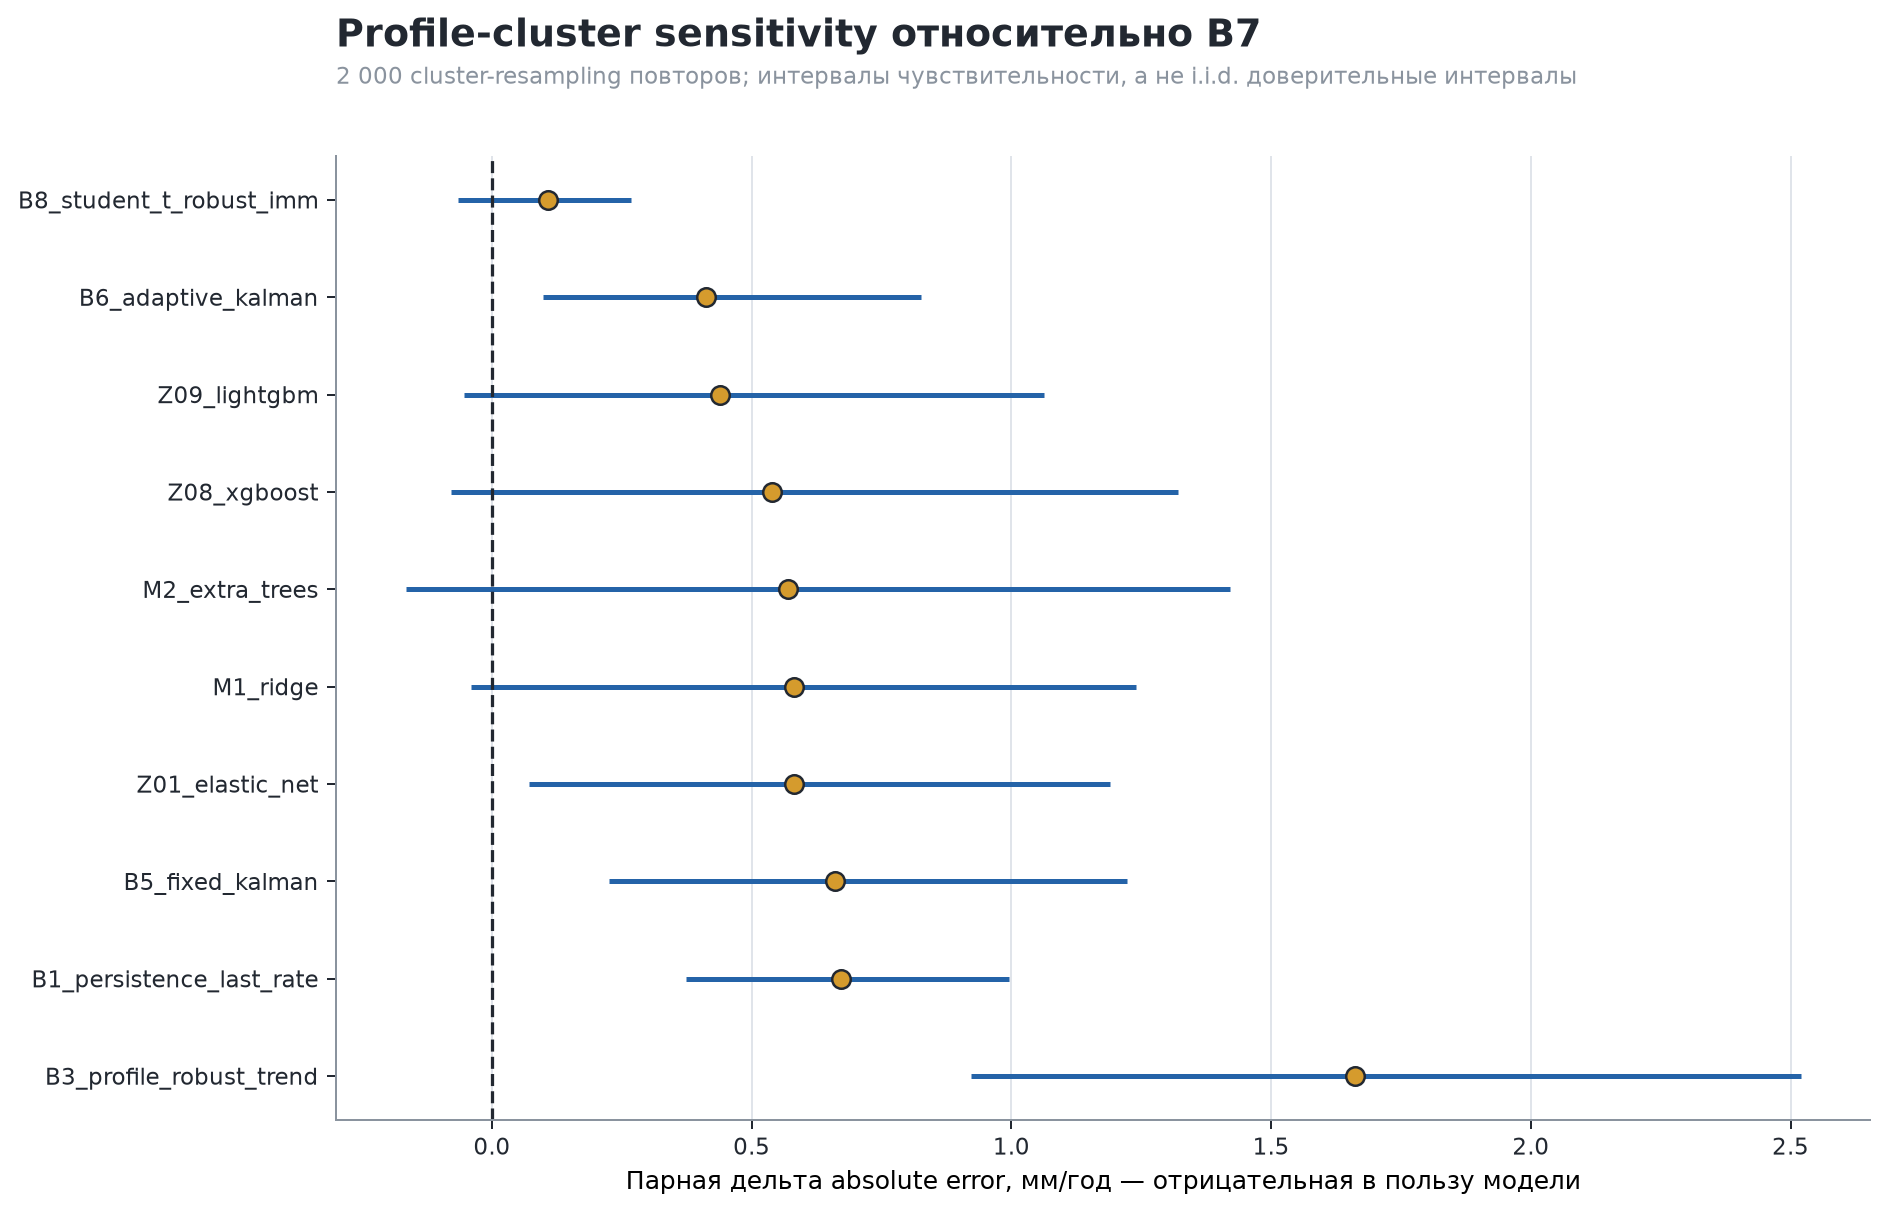

In [10]:
display(Image(filename=str(figure_root / '06_learning_curves.png'), width=1100))
display(Image(filename=str(figure_root / '07_profile_cluster_sensitivity.png'), width=1100))

In [11]:
learning.pivot(index='training_rows', columns='model_id', values='mae').round(3)

model_id,B1_persistence_last_rate,B3_profile_robust_trend,B5_fixed_kalman,B6_adaptive_kalman,B7_two_regime_imm,B8_student_t_robust_imm,M1_ridge,M2_extra_trees,Z01_elastic_net,Z08_xgboost,Z09_lightgbm
training_rows,,,,,,,,,,,
217,6.104,8.324,7.194,6.781,6.014,5.805,7.169,6.777,7.396,7.151,7.747
423,6.104,8.380,7.194,6.770,6.015,5.832,6.709,6.510,6.727,7.191,7.746
708,6.104,8.456,7.194,6.770,6.017,5.834,6.800,6.570,6.537,7.239,8.072
823,6.104,8.486,7.194,6.775,6.015,5.831,6.799,6.598,6.529,7.110,7.148


Learning curves являются диагностикой объёма данных: параметры заморожены и на кривых не перенастраиваются. Cluster-resampling intervals — sensitivity evidence при малом числе кластеров, а не i.i.d. inferential confidence intervals.

## 5. Governance, исключения и frozen suite v4

In [12]:
pd.DataFrame(suite['models'])[['model_id', 'role', 'model_spec_sha256']]

,model_id,role,model_spec_sha256
0,B1_persistence_last_rate,context_only_comparator,ac7010f31091c2f98f5daadd8791f9c16891a9d35a86fe...
1,B5_fixed_kalman,context_only_comparator,4494e2867936d8711b9da7b12fc503322d3a94cf447f9e...
2,B6_adaptive_kalman,context_only_comparator,c371eec79ca995e66cc8f00c31aca764b996ac5d956344...
3,B7_two_regime_imm,primary,3f5b40e28b1abb881a3a8158b999cee3c9c6fa8bdabfc6...
4,B8_student_t_robust_imm,context_only_comparator,175aad53ca092561e3179b23be25049e797a2aa4284880...
5,Z01_elastic_net,context_only,51fbe547a014ba97efa5ed4bbfc991c4a66cce4c7001f0...


In [13]:
pd.DataFrame([{
    'model_id': external['model_id'],
    'status': external['status'],
    'weights_downloaded': external['weights_downloaded'],
    'license_marker_present': external['license_marker_present'],
    'execution_allowed': external['execution_allowed'],
    'scientific_status': external['scientific_status'],
}])

,model_id,status,weights_downloaded,license_marker_present,execution_allowed,scientific_status
0,Z15_tabpfn_v2_6,EXCLUDED_GOVERNANCE_USER_WITHDRAWAL,False,False,False,NOT_EVALUATED


In [14]:
assert report['historical_validation_loaded'] is False
assert report['current_t1_test_loaded'] is False
assert report['new_holdout_seen'] is False
assert suite['primary_count'] == 1
assert suite['primary_selected_from_holdout'] is False
assert validation['status'] == 'PASS' and validation['summary']['failed'] == 0
assert all(item['status'] == 'READY' for item in environment['environments'].values())
assert external['status'] == 'EXCLUDED_GOVERNANCE_USER_WITHDRAWAL'
assert external['weights_downloaded'] is False
assert external['license_marker_present'] is False
assert external['execution_allowed'] is False
assert analytics['model_training_calls'] == 0
assert chart_map['model_training_calls'] == 0
assert len(chart_map['charts']) == 7
{
    'scope': report['scientific_scope'],
    'primary': suite['primary_model_id'],
    'qa': validation['summary'],
    'tabpfn': external['status'],
    'external_quality_claim_allowed': report['final_quality_claim_allowed'],
}

{'scope': 'train_only_internal_research',
 'primary': 'B7_two_regime_imm',
 'qa': {'checks': 106, 'failed': 0, 'passed': 106},
 'tabpfn': 'EXCLUDED_GOVERNANCE_USER_WITHDRAWAL',
 'external_quality_claim_allowed': False}

## Вывод и следующий шаг

Gate B6 завершён корректным статусом `PASS_NO_NEW_PRIMARY`: ни одна новая модель не прошла все заранее зафиксированные eligibility gates, поэтому B7 остаётся primary. Это не отрицательный software result, а ожидаемый научный исход строгого screening.

Следующий выбор модели разрешён только после появления заранее замороженного future/external holdout. До этого можно улучшать только доказательную базу и проводить новые nested train-only исследования с новой preregistration; текущие validation/test не могут стать источником настройки.